# Imitation Learning

## 1. Motivation

Suppose we already have an expert capable of solving a control task.

The expert could be:

- a human operator,
- an MPC controller,
- an optimal controller,
- another trained policy.

Instead of manually designing a new controller, we can collect demonstrations
from the expert and learn a policy that reproduces the expert's behavior.

Suppose the expert follows:

$$
u_t=
\pi_E(x_t),
$$

where $\pi_E$ is the expert policy.

We collect demonstrations:

$$
\mathcal D=
\{
(x_t,u_t)
\}_{t=1}^{N}.
$$

The goal is to learn a parameterized policy:

$$
\pi_\theta(x_t)
\approx
\pi_E(x_t).
$$

Therefore:

$$
\boxed{
\text{Expert}
\rightarrow
\text{Demonstrations}
\rightarrow
\text{Learned Policy}
}
$$

This is the basic idea behind **Imitation Learning**.

## 2. Two Main Approaches

Two important approaches to imitation learning are:

### Behavior Cloning

Behavior Cloning directly learns the expert policy:

$$
\boxed{
x
\rightarrow
u
}
$$

Given expert demonstrations:

$$
\mathcal D=
\{(x_i,u_i^{E})\},
$$

we train:

$$
\pi_\theta(x_i)
\approx
u_i^{E}.
$$

This converts imitation learning into a supervised learning problem.

---

### Inverse Reinforcement Learning

Inverse Reinforcement Learning asks a different question.

Instead of directly copying the expert's actions, we try to infer the
objective that explains the expert's behavior.

Conceptually:

$$
\text{Expert Demonstrations}
\rightarrow
\boxed{\text{Infer Reward / Cost}}
\rightarrow
\text{Solve Control Problem}.
$$

Thus:

$$
\boxed{
\text{Behavior Cloning}
\rightarrow
\text{learn what the expert does}
}
$$

while:

$$
\boxed{
\text{Inverse Reinforcement Learning}
\rightarrow
\text{learn why the expert behaves that way}
}
$$

## 3. Behavior Cloning as Supervised Learning

Behavior Cloning converts imitation learning into a supervised learning
problem.

Suppose the expert follows a policy:

$$
u_t^E = \pi_E(x_t).
$$

From expert demonstrations, we construct:

$$
\mathcal D=
\{(x_i,u_i^E)\}_{i=1}^{N}.
$$

A parameterized policy $\pi_\theta$ is then trained to predict the expert
action:

$$
\pi_\theta(x_i)
\approx
u_i^E.
$$

For continuous actions, a simple objective is mean squared error:

$$
J(\theta)=
\frac{1}{N}
\sum_{i=1}^{N}
\left\|
\pi_\theta(x_i)-u_i^E
\right\|^2.
$$

Training therefore follows the standard supervised-learning pipeline:

$$
\boxed{
x_i
\rightarrow
\pi_\theta
\rightarrow
\hat u_i
\rightarrow
\text{compare with }u_i^E
\rightarrow
\text{update }\theta
}
$$

Unlike system identification, the learning target is no longer the system
dynamics.

Instead, we directly learn the mapping from observation to action:

$$
\boxed{
\text{System Identification: }
(x,u,x') \rightarrow \hat f
}
$$

$$
\boxed{
\text{Behavior Cloning: }
x \rightarrow \pi_\theta(x)
}
$$

## 4. Expert Policy

To generate demonstrations, we first need an expert.

Consider a vehicle whose objective is to track a desired velocity:

$$
v_{\text{ref}}.
$$

We define a simple expert controller:

$$
u^E=
K_p(v_{\text{ref}}-v).
$$

The control command is limited to:

$$
u_{\min}
\leq
u^E
\leq
u_{\max}.
$$

The expert therefore defines a mapping:

$$
\boxed{
x
\rightarrow
u^E
}
$$

which can be observed and imitated by the learned policy.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

V_REF = 10.0
KP = 0.8

U_MIN = -3.0
U_MAX = 3.0


def expert_policy(state):

    position, velocity = state

    velocity_error = (
        V_REF - velocity
    )

    u = (
        KP * velocity_error
    )

    return np.clip(
        u,
        U_MIN,
        U_MAX
    )

In [3]:
test_states = [
    np.array([0.0, 0.0]),
    np.array([5.0, 5.0]),
    np.array([20.0, 9.0]),
    np.array([30.0, 12.0])
]

for state in test_states:

    print(
        "state =", state,
        "| expert action =",
        expert_policy(state)
    )

state = [0. 0.] | expert action = 3.0
state = [5. 5.] | expert action = 3.0
state = [20.  9.] | expert action = 0.8
state = [30. 12.] | expert action = -1.6


## 5. Collecting Expert Demonstrations

Behavior Cloning requires a dataset of expert state-action pairs:

$$
\mathcal D=
\{(x_i,u_i^E)\}.
$$

The quality and coverage of this dataset are important.

If demonstrations cover only a small region of the state space, the learned
policy may perform well inside that region but behave unpredictably when it
encounters unfamiliar states.

For this first experiment, we generate states across a range of positions and
velocities and query the expert for the corresponding action.

In [4]:
np.random.seed(0)

N_SAMPLES = 2000

states = []
expert_actions = []

for _ in range(N_SAMPLES):

    position = np.random.uniform(
        0.0,
        100.0
    )

    velocity = np.random.uniform(
        0.0,
        15.0
    )

    state = np.array([
        position,
        velocity
    ])

    action = expert_policy(
        state
    )

    states.append(
        state
    )

    expert_actions.append(
        action
    )

states = np.array(states)

expert_actions = np.array(
    expert_actions
).reshape(-1, 1)

print("States:", states.shape)
print("Actions:", expert_actions.shape)

States: (2000, 2)
Actions: (2000, 1)


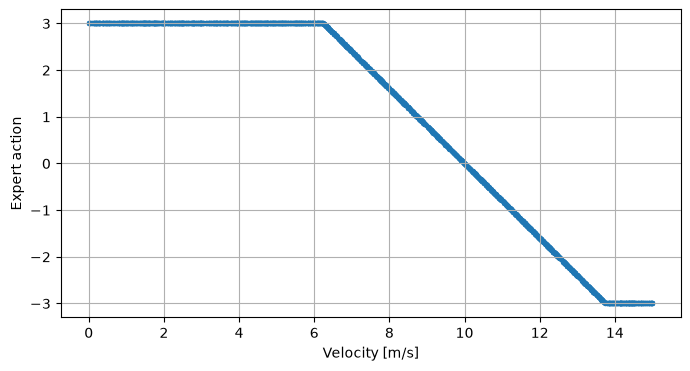

In [5]:
plt.figure(figsize=(8, 4))

plt.scatter(
    states[:, 1],
    expert_actions[:, 0],
    s=8
)

plt.xlabel("Velocity [m/s]")
plt.ylabel("Expert action")
plt.grid()

plt.show()

## 6. Neural Behavior-Cloning Policy

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim


class BCPolicy(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.network(x)

In [7]:
policy = BCPolicy()

optimizer = optim.Adam(
    policy.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

## 7. Preparing the Training Data

The expert demonstration dataset contains:

$$
\mathcal D=
\{(x_i,u_i^E)\}_{i=1}^{N}.
$$

Before training the neural policy, we normalize the state inputs.

For each state dimension:

$$
\tilde{x}=
\frac{x-\mu_x}{\sigma_x}.
$$

Normalization places different state variables on comparable numerical scales
and generally makes neural-network optimization easier.

The expert actions remain the training targets:

$$
\tilde{x}_i
\rightarrow
\pi_\theta
\rightarrow
\hat{u}_i
$$

and the training objective is:

$$
J(\theta)=
\frac{1}{N}
\sum_i
\left\|
\hat{u}_i-u_i^E
\right\|^2.
$$

In [8]:
state_mean = states.mean(
    axis=0
)

state_std = states.std(
    axis=0
) + 1e-8

states_normalized = (
    states - state_mean
) / state_std

In [9]:
X = torch.tensor(
    states_normalized,
    dtype=torch.float32
)

Y = torch.tensor(
    expert_actions,
    dtype=torch.float32
)

print("X:", X.shape)
print("Y:", Y.shape)

X: torch.Size([2000, 2])
Y: torch.Size([2000, 1])


## 9. Training the Behavior-Cloning Policy

Behavior Cloning trains the policy using ordinary supervised learning.

For each expert demonstration:

$$
(x_i,u_i^E),
$$

the policy predicts:

$$
\hat{u}_i=
\pi_\theta(x_i).
$$

The prediction is compared with the expert action using:

$$
L(\theta)=
\frac{1}{N}
\sum_i
\left(
\pi_\theta(x_i)-u_i^E
\right)^2.
$$

Gradient-based optimization updates the policy parameters:

$$
\theta
\leftarrow
\theta-
\alpha\nabla_\theta L.
$$

The important point is that the policy is not interacting with the environment
during this training step.

It is simply learning from a fixed dataset of expert demonstrations.

In [10]:
N_EPOCHS = 1000

loss_history = []

for epoch in range(N_EPOCHS):

    # Forward pass
    predicted_actions = policy(X)

    # Imitation loss
    loss = criterion(
        predicted_actions,
        Y
    )

    # Gradient update
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss.item():.6f}"
        )

Epoch    0 | Loss: 6.306257
Epoch  100 | Loss: 0.375647
Epoch  200 | Loss: 0.086657
Epoch  300 | Loss: 0.054284
Epoch  400 | Loss: 0.030671
Epoch  500 | Loss: 0.016731
Epoch  600 | Loss: 0.009717
Epoch  700 | Loss: 0.006502
Epoch  800 | Loss: 0.004795
Epoch  900 | Loss: 0.003970


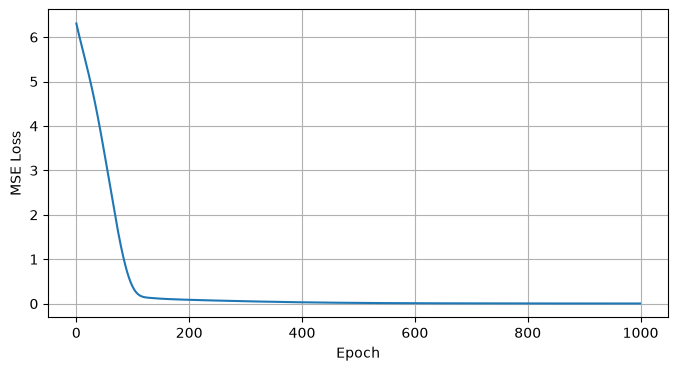

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()

plt.show()

In [12]:
velocity_grid = np.linspace(
    0.0,
    15.0,
    200
)

expert_grid = []
learned_grid = []

for velocity in velocity_grid:

    state = np.array([
        50.0,
        velocity
    ])

    # Expert
    expert_action = expert_policy(
        state
    )

    # Normalize state
    state_normalized = (
        state - state_mean
    ) / state_std

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32
    ).unsqueeze(0)

    # Learned policy
    with torch.no_grad():

        learned_action = policy(
            state_tensor
        ).item()

    expert_grid.append(
        expert_action
    )

    learned_grid.append(
        learned_action
    )

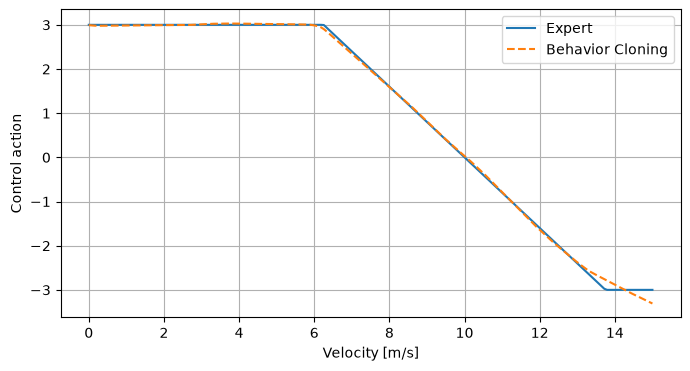

In [13]:
plt.figure(figsize=(8, 4))

plt.plot(
    velocity_grid,
    expert_grid,
    label="Expert"
)

plt.plot(
    velocity_grid,
    learned_grid,
    linestyle="--",
    label="Behavior Cloning"
)

plt.xlabel("Velocity [m/s]")
plt.ylabel("Control action")
plt.legend()
plt.grid()

plt.show()

## 10. Closed-Loop Deployment

A low supervised-learning error does not automatically guarantee good
closed-loop control.

During training, the policy observes states from the expert dataset:

$$
x \sim d_E(x),
$$

where $d_E$ is the state distribution generated by the expert.

During deployment, however, the learned policy controls the system itself:

$$
u_t=
\pi_\theta(x_t),
$$

$$
x_{t+1}=
f(x_t,u_t).
$$

Therefore, the learned policy determines which states it will encounter in
the future.

A small action error can change the next state:

$$
\pi_\theta(x_t)
\neq
\pi_E(x_t)
$$

$$
\Downarrow
$$

$$
x_{t+1}^{\pi_\theta}
\neq
x_{t+1}^{E}.
$$

The policy may then encounter states that were uncommon or absent in the
expert demonstrations.

This creates a mismatch between:

$$
\boxed{\text{training-state distribution}}
$$

and

$$
\boxed{\text{deployment-state distribution}}.
$$

This problem is known as **covariate shift**.

## 11. Closed-Loop Comparison: Expert vs Behavior Cloning

So far, the learned policy has been evaluated by comparing its predicted
actions with expert actions.

However, a control policy must ultimately be evaluated while interacting
with the dynamical system.

Consider the vehicle dynamics:

$$
p_{t+1}=
p_t+\Delta t\,v_t
$$

$$
v_{t+1}=
v_t+\Delta t\,u_t.
$$

We deploy two controllers independently from the same initial condition:

1. the original expert policy,
2. the learned Behavior Cloning policy.

For the expert:

$$
u_t^E=
\pi_E(x_t^E),
$$

$$
x_{t+1}^E=
f(x_t^E,u_t^E).
$$

For the learned policy:

$$
u_t^{BC}=
\pi_\theta(x_t^{BC}),
$$

$$
x_{t+1}^{BC}=
f(x_t^{BC},u_t^{BC}).
$$

Importantly, after the first timestep the two policies may encounter
different states.

Therefore, closed-loop evaluation tests not only action prediction accuracy,
but also whether the learned policy can maintain good behavior over time.

In [14]:
DT = 0.1


def vehicle_dynamics(state, u):

    position, velocity = state

    position_next = (
        position
        + DT * velocity
    )

    velocity_next = (
        velocity
        + DT * u
    )

    return np.array([
        position_next,
        velocity_next
    ])

In [15]:
def bc_policy(state):

    state_normalized = (
        state - state_mean
    ) / state_std

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        action = policy(
            state_tensor
        ).item()

    return np.clip(
        action,
        U_MIN,
        U_MAX
    )

In [16]:
N_STEPS = 150

initial_state = np.array([
    0.0,
    0.0
])

state_expert = initial_state.copy()
state_bc = initial_state.copy()

expert_velocity = []
bc_velocity = []

expert_control = []
bc_control = []

for k in range(N_STEPS):

    # -----------------------------
    # Expert
    # -----------------------------

    u_expert = expert_policy(
        state_expert
    )

    expert_velocity.append(
        state_expert[1]
    )

    expert_control.append(
        u_expert
    )

    state_expert = vehicle_dynamics(
        state_expert,
        u_expert
    )

    # -----------------------------
    # Behavior Cloning
    # -----------------------------

    u_bc = bc_policy(
        state_bc
    )

    bc_velocity.append(
        state_bc[1]
    )

    bc_control.append(
        u_bc
    )

    state_bc = vehicle_dynamics(
        state_bc,
        u_bc
    )

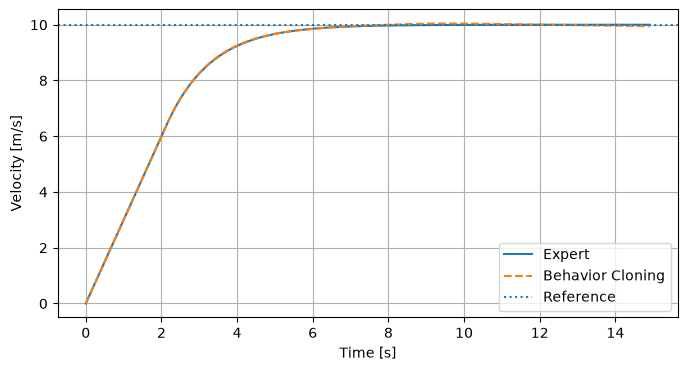

In [17]:
time = (
    np.arange(N_STEPS)
    * DT
)

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    expert_velocity,
    label="Expert"
)

plt.plot(
    time,
    bc_velocity,
    linestyle="--",
    label="Behavior Cloning"
)

plt.axhline(
    V_REF,
    linestyle=":",
    label="Reference"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.grid()

plt.show()

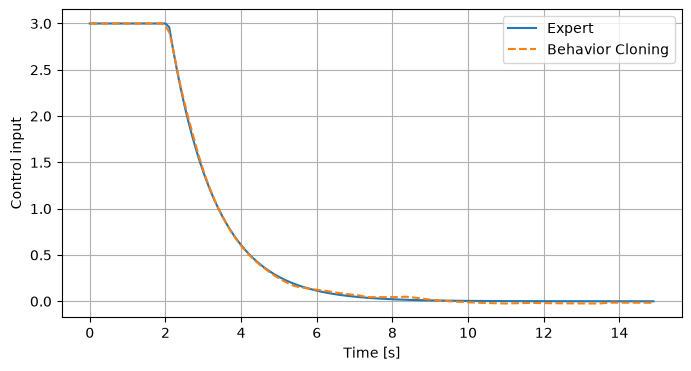

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    expert_control,
    label="Expert"
)

plt.plot(
    time,
    bc_control,
    linestyle="--",
    label="Behavior Cloning"
)

plt.xlabel("Time [s]")
plt.ylabel("Control input")
plt.legend()
plt.grid()

plt.show()

## 12. Covariate Shift

Behavior Cloning is trained using states generated by the expert:

$$
x \sim d_E(x),
$$

where $d_E$ represents the expert's state distribution.

During deployment, however, states are generated by the learned policy:

$$
x \sim d_{\pi_\theta}(x).
$$

If the learned policy makes a small action error,

$$
u_t^{BC}
\neq
u_t^E,
$$

then the resulting next state may also differ:

$$
x_{t+1}^{BC}
\neq
x_{t+1}^{E}.
$$

The learned policy may therefore encounter states that were rare or absent
in the expert demonstrations.

Thus:

$$
\boxed{
d_{\pi_\theta}(x)
\neq
d_E(x)
}
$$

This mismatch between the training distribution and the deployment
distribution is called **covariate shift**.

The problem is particularly important in sequential decision-making because
the policy's predictions influence its own future inputs.

## 13. Effect of Limited Demonstration Coverage

The previous Behavior Cloning dataset covered a broad range of velocities:

$$
v \in [0,15].
$$

This makes imitation relatively easy because the learned policy has training
examples for most states encountered during deployment.

In practice, expert demonstrations often cover only a limited region of the
state space.

To illustrate this problem, we now construct a dataset containing only:

$$
v \in [8,12].
$$

The policy therefore receives good demonstrations near the desired operating
velocity but receives no information about how the expert behaves at much
lower or higher velocities.

We will then deploy the learned policy from:

$$
v_0=0.
$$

This deliberately creates a distribution mismatch:

$$
\boxed{
\text{training: } v\in[8,12]
}
$$

$$
\boxed{
\text{deployment starts at: } v=0
}
$$

The experiment demonstrates why low imitation error on the expert dataset
does not necessarily imply good closed-loop performance.

In [19]:
np.random.seed(1)

N_LIMITED = 1000

states_limited = []
actions_limited = []

for _ in range(N_LIMITED):

    position = np.random.uniform(
        0.0,
        100.0
    )

    velocity = np.random.uniform(
        8.0,
        12.0
    )

    state = np.array([
        position,
        velocity
    ])

    action = expert_policy(
        state
    )

    states_limited.append(
        state
    )

    actions_limited.append(
        action
    )

states_limited = np.array(
    states_limited
)

actions_limited = np.array(
    actions_limited
).reshape(-1, 1)

In [20]:
limited_mean = states_limited.mean(
    axis=0
)

limited_std = states_limited.std(
    axis=0
) + 1e-8

X_limited = torch.tensor(
    (states_limited - limited_mean)
    / limited_std,
    dtype=torch.float32
)

Y_limited = torch.tensor(
    actions_limited,
    dtype=torch.float32
)

In [21]:
limited_policy = BCPolicy()

limited_optimizer = optim.Adam(
    limited_policy.parameters(),
    lr=1e-3
)

limited_loss_history = []

In [24]:
for epoch in range(1000):

    predicted_actions = limited_policy(
        X_limited
    )

    loss = criterion(
        predicted_actions,
        Y_limited
    )

    limited_optimizer.zero_grad()

    loss.backward()

    limited_optimizer.step()

    limited_loss_history.append(
        loss.item()
    )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss.item():.6f}"
        )

Epoch    0 | Loss: 0.000028
Epoch  100 | Loss: 0.000025
Epoch  200 | Loss: 0.000023
Epoch  300 | Loss: 0.000021
Epoch  400 | Loss: 0.000019
Epoch  500 | Loss: 0.000017
Epoch  600 | Loss: 0.000016
Epoch  700 | Loss: 0.000015
Epoch  800 | Loss: 0.000013
Epoch  900 | Loss: 0.000012


## 14. In-Distribution vs Out-of-Distribution Behavior

A learned policy can behave very differently depending on whether its input
resembles the states seen during training.

We distinguish between:

### In-distribution states

States similar to the demonstrations:

$$
x \sim d_E.
$$

### Out-of-distribution states

States outside or far from the demonstrated region:

$$
x \not\sim d_E.
$$

Behavior Cloning directly constrains the policy only on demonstrated states.

Outside that region, the neural network is effectively extrapolating.

Therefore, good imitation performance on the training distribution does not
guarantee sensible behavior outside it.

In [25]:
velocity_grid = np.linspace(
    0.0,
    15.0,
    200
)

expert_grid = []
limited_bc_grid = []

for velocity in velocity_grid:

    state = np.array([
        50.0,
        velocity
    ])

    expert_grid.append(
        expert_policy(state)
    )

    state_normalized = (
        state - limited_mean
    ) / limited_std

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        action = limited_policy(
            state_tensor
        ).item()

    limited_bc_grid.append(
        action
    )

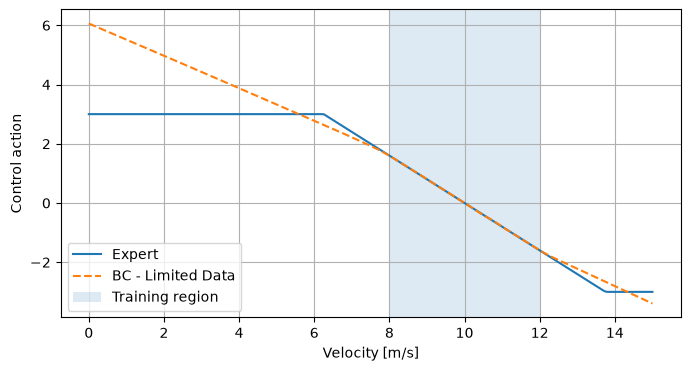

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    velocity_grid,
    expert_grid,
    label="Expert"
)

plt.plot(
    velocity_grid,
    limited_bc_grid,
    linestyle="--",
    label="BC - Limited Data"
)

plt.axvspan(
    8.0,
    12.0,
    alpha=0.15,
    label="Training region"
)

plt.xlabel("Velocity [m/s]")
plt.ylabel("Control action")
plt.legend()
plt.grid()

plt.show()

## 15. Compounding Errors

In ordinary supervised learning, a prediction error affects the current
prediction.

In sequential control, a prediction error can also affect future inputs.

Suppose the learned policy makes a small error:

$$
u_t^{BC}=
u_t^E+\delta_t.
$$

Because the action enters the system dynamics:

$$
x_{t+1}=
f(x_t,u_t),
$$

the resulting state differs from the expert trajectory:

$$
x_{t+1}^{BC}
\neq
x_{t+1}^{E}.
$$

The next action is therefore evaluated at a different state:

$$
u_{t+1}^{BC}=
\pi_\theta(x_{t+1}^{BC}).
$$

If this new state is less represented in the expert dataset, the next
prediction may be worse.

This creates a feedback mechanism:

$$
\boxed{
\text{action error}
\rightarrow
\text{state deviation}
\rightarrow
\text{distribution shift}
\rightarrow
\text{larger action error}
\rightarrow
\cdots
}
$$

Thus, small imitation errors can accumulate over a trajectory.

This phenomenon is known as **compounding error** and is one of the main
limitations of naive Behavior Cloning.

## 16. Fixing Covariate Shift: Dataset Aggregation

The main weakness of naive Behavior Cloning is that the training dataset is
generated by the expert:

$$
x \sim d_{\pi_E},
$$

while deployment states are generated by the learned policy:

$$
x \sim d_{\pi_\theta}.
$$

A natural solution is to collect training data from the states that the
learner itself encounters.

The procedure becomes:

1. Train an initial policy using expert demonstrations.
2. Deploy the learned policy.
3. Collect the states visited by the learned policy.
4. Ask the expert for the correct action at those states.
5. Add the new state-action pairs to the dataset.
6. Retrain the policy.
7. Repeat.

If the learner visits a state $x_t$ where it does not know the correct action,
the expert provides:

$$
u_t^E = \pi_E(x_t).
$$

The new demonstration is added to the dataset:

$$
\mathcal D
\leftarrow
\mathcal D
\cup
\{(x_t,u_t^E)\}.
$$

This approach is known as **Dataset Aggregation (DAgger)**.

Conceptually:

$$
\boxed{
\text{Learner visits states}
\rightarrow
\text{Expert labels them}
\rightarrow
\text{Dataset expands}
\rightarrow
\text{Policy improves}
}
$$

Unlike naive Behavior Cloning, the training dataset gradually includes states
from the learner's own state distribution.

## 17. Simple DAgger Experiment

Our limited Behavior Cloning policy was trained only on:

$$
v\in[8,12].
$$

However, deployment begins at:

$$
v_0=0.
$$

We now allow the learned policy to control the vehicle and record the states
that it actually visits.

For every visited state $x_t$, we query the expert:

$$
u_t^E=
\pi_E(x_t).
$$

Notice an important distinction:

The action used to move the system is generated by the **learner**:

$$
u_t=
\pi_\theta(x_t),
$$

but the training label stored in the dataset is generated by the **expert**:

$$
(x_t,\pi_E(x_t)).
$$

The resulting data therefore teaches the learner what it should have done in
states arising from its own behavior.

In [27]:
def limited_bc_policy(state):

    state_normalized = (
        state - limited_mean
    ) / limited_std

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        action = limited_policy(
            state_tensor
        ).item()

    return np.clip(
        action,
        U_MIN,
        U_MAX
    )

In [28]:
state = np.array([
    0.0,
    0.0
])

dagger_states = []
dagger_actions = []

N_DAGGER_STEPS = 150

for k in range(N_DAGGER_STEPS):

    # Learner decides what action to execute
    learner_action = limited_bc_policy(
        state
    )

    # Expert labels the learner's current state
    expert_action = expert_policy(
        state
    )

    dagger_states.append(
        state.copy()
    )

    dagger_actions.append(
        expert_action
    )

    # Environment evolves using learner action
    state = vehicle_dynamics(
        state,
        learner_action
    )

In [29]:
dagger_states = np.array(
    dagger_states
)

dagger_actions = np.array(
    dagger_actions
).reshape(-1, 1)

print(
    "Visited velocity range:",
    dagger_states[:, 1].min(),
    "to",
    dagger_states[:, 1].max()
)

Visited velocity range: 0.0 to 10.04209266975523


## 18. Aggregating the Demonstrations

DAgger does not discard the original expert demonstrations.

Instead, the newly labeled learner states are added to the existing dataset:

$$
\mathcal D_{\text{new}}=
\mathcal D_{\text{old}}
\cup
\mathcal D_{\text{learner}}.
$$

The original dataset contains states generated by the expert distribution,
while the new samples contain states encountered by the learned policy.

As this process is repeated, the dataset becomes increasingly representative
of states that matter during actual deployment.

The important idea is:

$$
\boxed{
\text{Do not only learn how the expert acts where the expert goes.}
}
$$

Instead:

$$
\boxed{
\text{Learn what the expert would do where the learner goes.}
}
$$

In [30]:
states_aggregated = np.concatenate(
    [
        states_limited,
        dagger_states
    ],
    axis=0
)

actions_aggregated = np.concatenate(
    [
        actions_limited,
        dagger_actions
    ],
    axis=0
)

print(
    states_aggregated.shape,
    actions_aggregated.shape
)

(1150, 2) (1150, 1)


In [31]:
dagger_mean = states_aggregated.mean(
    axis=0
)

dagger_std = states_aggregated.std(
    axis=0
) + 1e-8

X_dagger = torch.tensor(
    (
        states_aggregated
        - dagger_mean
    )
    / dagger_std,
    dtype=torch.float32
)

Y_dagger = torch.tensor(
    actions_aggregated,
    dtype=torch.float32
)

In [33]:
dagger_policy = BCPolicy()

dagger_optimizer = optim.Adam(
    dagger_policy.parameters(),
    lr=1e-3
)

dagger_loss_history = []

for epoch in range(1000):

    predicted_actions = dagger_policy(
        X_dagger
    )

    loss = criterion(
        predicted_actions,
        Y_dagger
    )

    dagger_optimizer.zero_grad()

    loss.backward()

    dagger_optimizer.step()

    dagger_loss_history.append(
        loss.item()
    )

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss.item():.6f}"
        )

Epoch    0 | Loss: 0.926930
Epoch  100 | Loss: 0.024780
Epoch  200 | Loss: 0.009248
Epoch  300 | Loss: 0.005309
Epoch  400 | Loss: 0.002846
Epoch  500 | Loss: 0.001517
Epoch  600 | Loss: 0.000860
Epoch  700 | Loss: 0.000468
Epoch  800 | Loss: 0.000289
Epoch  900 | Loss: 0.000188


## 19. Evaluating the DAgger Policy

We can now compare three controllers:

1. the expert policy,
2. Behavior Cloning trained on limited expert data,
3. Behavior Cloning after dataset aggregation.

The important comparison is not only supervised prediction error.

We want to evaluate the policies **closed-loop**, because the learned actions
determine future states.

If dataset aggregation works as intended, the updated policy should perform
better in regions that were absent from the original demonstrations.

In [34]:
def dagger_bc_policy(state):

    state_normalized = (
        state - dagger_mean
    ) / dagger_std

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        action = dagger_policy(
            state_tensor
        ).item()

    return np.clip(
        action,
        U_MIN,
        U_MAX
    )

In [35]:
initial_state = np.array([
    0.0,
    0.0
])

state_expert = initial_state.copy()
state_limited = initial_state.copy()
state_dagger = initial_state.copy()

velocity_expert = []
velocity_limited = []
velocity_dagger = []

for k in range(N_STEPS):

    # Expert
    velocity_expert.append(
        state_expert[1]
    )

    u = expert_policy(
        state_expert
    )

    state_expert = vehicle_dynamics(
        state_expert,
        u
    )

    # Limited BC
    velocity_limited.append(
        state_limited[1]
    )

    u = limited_bc_policy(
        state_limited
    )

    state_limited = vehicle_dynamics(
        state_limited,
        u
    )

    # DAgger
    velocity_dagger.append(
        state_dagger[1]
    )

    u = dagger_bc_policy(
        state_dagger
    )

    state_dagger = vehicle_dynamics(
        state_dagger,
        u
    )

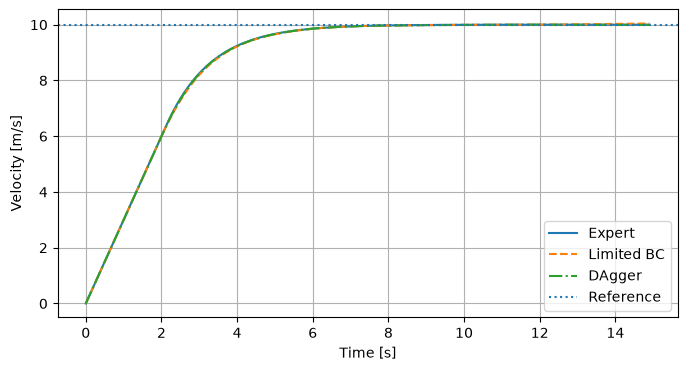

In [36]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    velocity_expert,
    label="Expert"
)

plt.plot(
    time,
    velocity_limited,
    linestyle="--",
    label="Limited BC"
)

plt.plot(
    time,
    velocity_dagger,
    linestyle="-.",
    label="DAgger"
)

plt.axhline(
    V_REF,
    linestyle=":",
    label="Reference"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.grid()

plt.show()

### Comparing Tracking Errors

When the three trajectories are close to each other, directly comparing the
velocity curves can make the differences difficult to see.

We therefore compute the deviation of each learned policy from the expert:

$$
e_t^{BC}=
v_t^{BC}-
v_t^{E}
$$

and

$$
e_t^{DAgger}=
v_t^{DAgger}-
v_t^{E}.
$$

A policy that reproduces the expert more accurately should maintain an error
closer to zero.

This error plot is often more informative than plotting several nearly
overlapping trajectories.

In [37]:
velocity_expert_np = np.array(
    velocity_expert
)

velocity_limited_np = np.array(
    velocity_limited
)

velocity_dagger_np = np.array(
    velocity_dagger
)

error_limited = (
    velocity_limited_np
    - velocity_expert_np
)

error_dagger = (
    velocity_dagger_np
    - velocity_expert_np
)

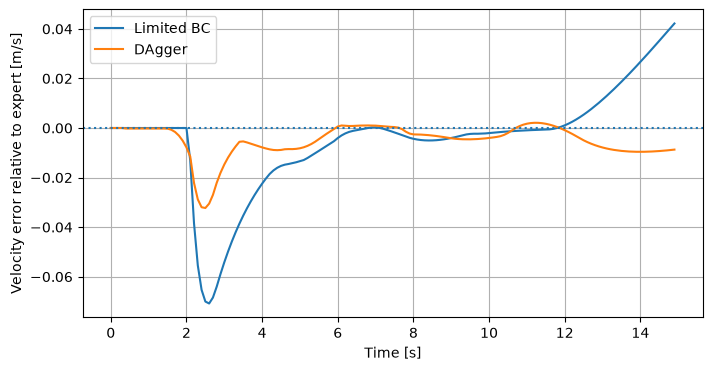

In [38]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    error_limited,
    label="Limited BC"
)

plt.plot(
    time,
    error_dagger,
    label="DAgger"
)

plt.axhline(
    0.0,
    linestyle=":"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity error relative to expert [m/s]")
plt.legend()
plt.grid()

plt.show()

### Quantitative Comparison

We can summarize the closed-loop deviation using the mean absolute error
relative to the expert:

$$
\text{MAE}=
\frac{1}{T}
\sum_{t=1}^{T}
\left|
v_t^{\text{policy}}-
v_t^{E}
\right|.
$$

Smaller values indicate behavior that remains closer to the expert trajectory
during closed-loop execution.

In [39]:
mae_limited = np.mean(
    np.abs(error_limited)
)

mae_dagger = np.mean(
    np.abs(error_dagger)
)

print(
    f"Limited BC MAE : {mae_limited:.4f} m/s"
)

print(
    f"DAgger MAE     : {mae_dagger:.4f} m/s"
)

Limited BC MAE : 0.0123 m/s
DAgger MAE     : 0.0054 m/s


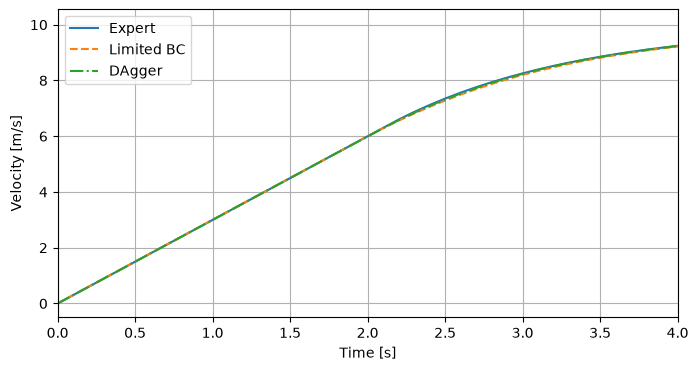

In [40]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    velocity_expert,
    label="Expert"
)

plt.plot(
    time,
    velocity_limited,
    linestyle="--",
    label="Limited BC"
)

plt.plot(
    time,
    velocity_dagger,
    linestyle="-.",
    label="DAgger"
)

plt.xlim(0, 4)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.grid()

plt.show()

### Closed-Loop Performance Metric

Once different policies are deployed independently, they generally encounter
different states:

$$
x_t^{E}
\neq
x_t^{BC}
\neq
x_t^{DAgger}.
$$

Therefore, directly comparing their control inputs at the same timestep can be
misleading, because each action is computed for a different state.

Instead, we compare how well each policy achieves the control objective.

For velocity tracking:

$$
e_t=
v_{\text{ref}}-
v_t.
$$

Thus:

$$
e_t^{BC}=
v_{\text{ref}}-
v_t^{BC}
$$

and:

$$
e_t^{DAgger}=
v_{\text{ref}}-
v_t^{DAgger}.
$$

A better policy should produce smaller tracking error during closed-loop
execution.

In [41]:
error_expert = (
    V_REF
    - np.array(velocity_expert)
)

error_limited = (
    V_REF
    - np.array(velocity_limited)
)

error_dagger = (
    V_REF
    - np.array(velocity_dagger)
)

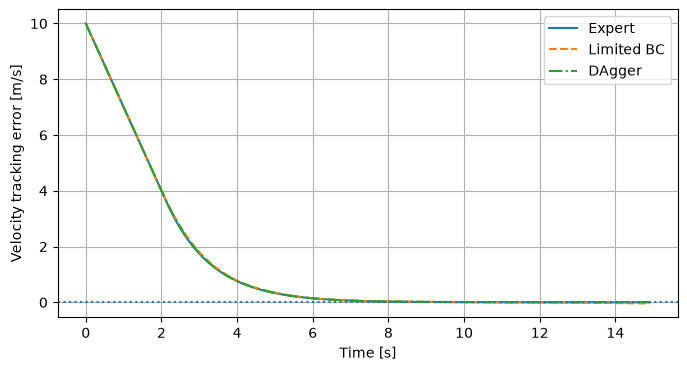

In [42]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    error_expert,
    label="Expert"
)

plt.plot(
    time,
    error_limited,
    linestyle="--",
    label="Limited BC"
)

plt.plot(
    time,
    error_dagger,
    linestyle="-.",
    label="DAgger"
)

plt.axhline(
    0.0,
    linestyle=":"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity tracking error [m/s]")
plt.legend()
plt.grid()

plt.show()

In [43]:
mae_expert = np.mean(
    np.abs(error_expert)
)

mae_limited = np.mean(
    np.abs(error_limited)
)

mae_dagger = np.mean(
    np.abs(error_dagger)
)

print(
    f"Expert MAE     : {mae_expert:.4f} m/s"
)

print(
    f"Limited BC MAE : {mae_limited:.4f} m/s"
)

print(
    f"DAgger MAE     : {mae_dagger:.4f} m/s"
)

Expert MAE     : 1.2883 m/s
Limited BC MAE : 1.3005 m/s
DAgger MAE     : 1.2934 m/s


## 20. Multimodal Expert Behavior

Another limitation of simple Behavior Cloning appears when expert behavior is
**multimodal**.

Suppose an obstacle can safely be avoided in two different ways:

$$
u^E=-1
\qquad
\text{(pass left)}
$$

or:

$$
u^E=+1
\qquad
\text{(pass right)}.
$$

Both actions may be correct.

If similar observations appear with both actions in the demonstration
dataset, a deterministic policy trained using mean squared error attempts to
minimize:

$$
\mathbb E
\left[
(\pi_\theta(x)-u^E)^2
\right].
$$

For squared-error regression, the optimal prediction corresponds to the
conditional mean:

$$
\pi_\theta(x)
\approx
\mathbb E[u^E|x].
$$

Therefore, if the demonstrations contain two equally likely actions:

$$
u^E\in\{-1,+1\},
$$

the learned prediction may become:

$$
\pi_\theta(x)\approx0.
$$

But:

$$
\boxed{
\text{average of valid actions}
\neq
\text{valid action}
}
$$

For an obstacle-avoidance problem, averaging "go left" and "go right" could
produce "go straight", which may be precisely the action that should be
avoided.

This is known as the **multimodality problem** in imitation learning.

## 21. Multimodality in Robotics

Multimodal behavior is common in robotics and autonomous systems.

For the same observation, multiple actions or trajectories may be valid.

Examples include:

- passing an obstacle on the left or right,
- grasping an object using different grasp poses,
- approaching an object from different directions,
- choosing different collision-free trajectories,
- performing the same manipulation task using different motion strategies.

A deterministic Behavior Cloning policy trained with simple MSE tends to
compress these possibilities into a single prediction.

For complex robot behavior, we therefore often want a policy capable of
representing a **distribution over actions or trajectories**:

$$
\boxed{
\pi_\theta(u|x)
}
$$

rather than only a deterministic mapping:

$$
\boxed{
u=\pi_\theta(x).
}
$$

This motivates richer imitation-learning models capable of representing
multiple valid behaviors.

## 22. Behavior Cloning vs Inverse Reinforcement Learning

Behavior Cloning and Inverse Reinforcement Learning both use expert
demonstrations, but they try to learn different things.

### Behavior Cloning

Behavior Cloning directly learns the expert's policy:

$$
\mathcal D=
\{(x_t,u_t^E)\}
$$

$$
\Downarrow
$$

$$
\boxed{
\pi_\theta(x)
\approx
\pi_E(x)
}
$$

The learner tries to reproduce the expert's action for a given state.

---

### Inverse Reinforcement Learning

Inverse Reinforcement Learning asks a different question:

> What objective or reward could explain the expert's behavior?

Instead of directly learning:

$$
x
\rightarrow
u,
$$

IRL attempts to infer a reward function:

$$
R_\theta(x,u)
$$

such that the expert's demonstrations are approximately optimal under that
reward.

Conceptually:

$$
\boxed{
\text{Expert Demonstrations}
\rightarrow
\text{Infer Reward}
\rightarrow
\text{Solve Control / RL Problem}
}
$$

Therefore:

$$
\boxed{
\text{Behavior Cloning learns the policy}
}
$$

while:

$$
\boxed{
\text{Inverse Reinforcement Learning learns the objective}
}
$$

## 23. Why Infer the Reward?

Suppose an expert produces a trajectory that avoids obstacles, stays near the
lane center, maintains a comfortable speed, and avoids aggressive steering.

Behavior Cloning observes only the resulting state-action pairs:

$$
(x_t,u_t^E).
$$

It learns to reproduce those actions.

However, the expert may actually be balancing several hidden objectives:

$$
R=
R_{\text{safety}}
+
R_{\text{progress}}
+
R_{\text{comfort}}
+
R_{\text{lane}}.
$$

Inverse Reinforcement Learning attempts to recover an objective that explains
the demonstrated behavior.

Once such a reward has been inferred, a new policy can in principle be
optimized under that reward.

This may allow the system to reason about situations that are different from
the exact demonstrations, because it has learned something about the
underlying objective rather than only copying individual actions.

## 24. Imitation Learning Summary

In this notebook, we moved from explicitly designed controllers to learned
policies.

The basic imitation-learning pipeline is:

$$
\boxed{
\text{Expert}
\rightarrow
\text{Demonstrations}
\rightarrow
\text{Learned Policy}
}
$$

### Behavior Cloning

Given expert demonstrations:

$$
\mathcal D=
\{(x_i,u_i^E)\},
$$

Behavior Cloning trains a policy:

$$
\pi_\theta(x)
\approx
u^E
$$

using supervised learning.

For continuous actions, a simple objective is:

$$
J(\theta)=
\frac{1}{N}
\sum_i
\left\|
\pi_\theta(x_i)-u_i^E
\right\|^2.
$$

---

### Closed-Loop Evaluation

A low supervised-learning loss is not sufficient.

During deployment:

$$
u_t=
\pi_\theta(x_t)
$$

and:

$$
x_{t+1}=
f(x_t,u_t).
$$

Therefore, policy errors influence future states.

This makes sequential decision-making fundamentally different from ordinary
static prediction.

---

### Covariate Shift

Behavior Cloning is trained mainly on:

$$
x\sim d_{\pi_E},
$$

but during deployment it experiences:

$$
x\sim d_{\pi_\theta}.
$$

The mismatch:

$$
d_{\pi_\theta}
\neq
d_{\pi_E}
$$

can lead to compounding errors.

---

### DAgger

Dataset Aggregation addresses this by allowing the learner to visit states
and asking the expert to label those states:

$$
x_t^{\pi_\theta}
\rightarrow
\pi_E(x_t).
$$

The new samples are added to the dataset:

$$
\mathcal D
\leftarrow
\mathcal D
\cup
\{(x_t,\pi_E(x_t))\}.
$$

This gradually improves coverage of states encountered by the learner.

---

### Multimodal Behavior

Expert behavior may contain several valid actions.

For example:

$$
u=-1
\qquad
\text{or}
\qquad
u=+1.
$$

A deterministic MSE policy may predict their mean:

$$
u\approx0,
$$

which may correspond to none of the valid behaviors.

This motivates probabilistic and generative policies:

$$
\pi_\theta(u|x).
$$

---

### Inverse Reinforcement Learning

Behavior Cloning learns:

$$
\boxed{
\text{state}
\rightarrow
\text{action}
}
$$

while Inverse Reinforcement Learning attempts to learn:

$$
\boxed{
\text{demonstrations}
\rightarrow
\text{reward / objective}
}
$$

## 25. From Imitation Learning to Reinforcement Learning

Imitation Learning assumes that an expert is available.

The learner receives examples of what action should be taken:

$$
(x_t,u_t^E).
$$

But what if no expert demonstrations are available?

Suppose instead that the system can interact with the environment and observe
a reward:

$$
(x_t,u_t,r_t,x_{t+1}).
$$

The learner must then discover which actions produce high long-term reward.

This leads to Reinforcement Learning.

The difference can be summarized as:

### Imitation Learning

$$
\boxed{
\text{Expert tells us what to do}
}
$$

### Reinforcement Learning

$$
\boxed{
\text{Reward tells us how well we did}
}
$$

In reinforcement learning, the learner must connect actions with future
consequences:

$$
u_t
\rightarrow
r_t
\rightarrow
x_{t+1}
\rightarrow
r_{t+1}
\rightarrow
\cdots
$$

Therefore, we return to the idea of long-term value:

$$
V^\pi(x)=
\mathbb E_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^k r_{t+k}
\mid
x_t=x
\right].
$$

We already encountered value functions and Bellman equations in Dynamic
Programming.

The next question is:

> What changes when the transition model is unknown and we have to learn from
> samples?

This leads to:

$$
\boxed{
\text{Dynamic Programming}
\rightarrow
\text{Monte Carlo}
\rightarrow
\text{Temporal Difference Learning}
}
$$